In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
# Load raw data as pandas dataframes
calendar = pd.read_csv("../data/raw/calendar.csv")
sales = pd.read_csv("../data/raw/sales_train_evaluation.csv")
prices = pd.read_csv("../data/raw/sell_prices.csv")
sales_valid = pd.read_csv("../data/raw/sales_train_validation.csv")

## Dataset Dimensions

In [39]:
# Check shape of data files
print("Calendar:", calendar.shape)
print("Sales:", sales.shape)
print("Prices:", prices.shape)
print("Sales Validation Data:", sales_valid.shape)

Calendar: (1969, 14)
Sales: (30490, 1947)
Prices: (6841121, 4)
Sales Validation Data: (30490, 1919)


# Overview of File Structures and Summary Statistics

## Calendar Dataset

In [33]:
# View structure of calendar file
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [34]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB


In [42]:
calendar.describe(include='all')

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
count,1969,1969.000000,1969,1969.000000,1969.000000,1969.000000,1969,162,162,5,5,1969.000000,1969.000000,1969.000000
unique,1969,NaN,7,NaN,NaN,NaN,1969,30,4,4,2,NaN,NaN,NaN
top,2011-01-29,NaN,Saturday,NaN,NaN,NaN,d_1,SuperBowl,Religious,Father's day,Cultural,NaN,NaN,NaN
freq,1,NaN,282,NaN,NaN,NaN,1,6,55,2,4,NaN,NaN,NaN
mean,NaN,11347.086338,NaN,3.997461,6.325546,2013.288471,NaN,NaN,NaN,NaN,NaN,0.330117,0.330117,0.330117
std,NaN,155.277043,NaN,2.001141,3.416864,1.580198,NaN,NaN,NaN,NaN,NaN,0.470374,0.470374,0.470374
min,NaN,11101.000000,NaN,1.000000,1.000000,2011.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,11219.000000,NaN,2.000000,3.000000,2012.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
50%,NaN,11337.000000,NaN,4.000000,6.000000,2013.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
75%,NaN,11502.000000,NaN,6.000000,9.000000,2015.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000


## Calendar Summary:
## Date Variables:
### Every date in the calendar dataset appears exactly once, there are 1969 total days.
### The dataset spans 2011-2016
### There are 7 weekdays included with Saturday appearing the most, 282 times. Days of the week are evenly distributed across the dataset.
### The mean value for 'month' is 6.33, which suggests that observations are spread across the year rather than concentrated in a single season.
## Events:
### There are 162 events over the timeframe, and 30 unique event names.
### It's possible that the event1 and event2 columns should be merged??
### The mean value for each SNAP variable is approximately 0.33, indicating SNAP benefits were active on roughly 33% of days in each state.
### 
### wm_yr_wk ranges from 11101 to 11621; This variable serves as Walmart's internal week identifier and is used to connect the calendar dataset with pricing information.

## Sales Dataset

In [5]:
# View structure of sales file
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [35]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1949 entries, id to item_num
dtypes: int64(1943), str(6)
memory usage: 453.4 MB


In [44]:
# Create summary columns for use in descriptive statistics of total sales

daily_cols = [c for c in sales.columns if c.startswith('d_')]

sales['total_sales'] = sales[daily_cols].sum(axis=1)

# Stats on how much a typical product sells over the timeframe:
sales['total_sales'].describe()

count     30490.000000
mean       2195.053231
std        5290.421671
min          15.000000
25%         366.000000
50%         868.000000
75%        2072.000000
max      253859.000000
Name: total_sales, dtype: float64

In [46]:
# total sales by category

sales.groupby('cat_id')['total_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
cat_id,,,,,,,,
FOODS,14370.0,3195.715170,7160.735606,15.0,614.0,1379.0,3033.0,253859.0
HOBBIES,5650.0,1104.540885,2015.367456,16.0,214.0,456.0,1052.5,30303.0
HOUSEHOLD,10470.0,1410.132760,2511.854055,23.0,293.0,640.0,1466.0,44018.0


In [47]:
# total sales by department

sales.groupby('dept_id')['total_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
dept_id,,,,,,,,
FOODS_1,2160.0,2402.962963,3453.986914,29.0,644.75,1335.5,2521.25,45195.0
FOODS_2,3980.0,1958.548995,3261.517415,16.0,447.00,1041.0,2174.25,49660.0
FOODS_3,8230.0,4002.065857,8927.836985,15.0,715.00,1589.0,3736.75,253859.0
HOBBIES_1,4160.0,1369.955288,2277.253246,16.0,276.75,607.0,1364.25,30303.0
HOBBIES_2,1490.0,363.518121,422.074780,28.0,138.00,240.5,419.00,5177.0
HOUSEHOLD_1,5320.0,2203.543797,3272.542508,23.0,552.00,1154.5,2423.00,44018.0
HOUSEHOLD_2,5150.0,590.531456,665.547678,23.0,198.00,383.0,717.00,7986.0


In [49]:
sales['cat_id'].value_counts()

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

In [50]:
sales['dept_id'].value_counts()

dept_id
FOODS_3        8230
HOUSEHOLD_1    5320
HOUSEHOLD_2    5150
HOBBIES_1      4160
FOODS_2        3980
FOODS_1        2160
HOBBIES_2      1490
Name: count, dtype: int64

In [51]:
sales['store_id'].value_counts()

store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: count, dtype: int64

In [52]:
sales['state_id'].value_counts()

state_id
CA    12196
TX     9147
WI     9147
Name: count, dtype: int64

## Prices Dataset

In [6]:
# View structure of prices file
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [36]:
prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 208.8 MB


In [53]:
prices.describe()

,wm_yr_wk,sell_price
count,6.841121e+06,6.841121e+06
mean,1.138294e+04,4.410952e+00
std,1.486100e+02,3.408814e+00
min,1.110100e+04,1.000000e-02
25%,1.124700e+04,2.180000e+00
50%,1.141100e+04,3.470000e+00
75%,1.151700e+04,5.840000e+00
max,1.162100e+04,1.073200e+02


## Sales Validation Dataset

In [40]:
# View structure of sales validation file
sales_valid.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [41]:
sales_valid.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 446.4 MB


# Check for Missing or Null Values

In [7]:
# Check for null values in calendar file
calendar.isnull().sum().sort_values(ascending=False)

event_name_2    1964
event_type_2    1964
event_name_1    1807
event_type_1    1807
date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

### For the event_name and event_type columns, these null values are expected for each day that is not a holiday. The Calendar dataset contains no missing values otherwise. 

In [8]:
# Check for null values in prices file
prices.isnull().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

### Pricing dataset contains no null values.

In [9]:
# Check for null values in sales file
sales.isnull().sum().sort_values(ascending=False).head(10)

id        0
d_1273    0
d_1301    0
d_1300    0
d_1299    0
d_1298    0
d_1297    0
d_1296    0
d_1295    0
d_1294    0
dtype: int64

### Sales dataset contains no null values.

# Distribution of Total Daily Sales

In [10]:
#aggregate the products together to show total daily sales

daily_cols = [c for c in sales.columns if c.startswith("d_")]

daily_sales = sales[daily_cols].sum()

daily_sales.head()

d_1    32631
d_2    31749
d_3    23783
d_4    25412
d_5    19146
dtype: int64

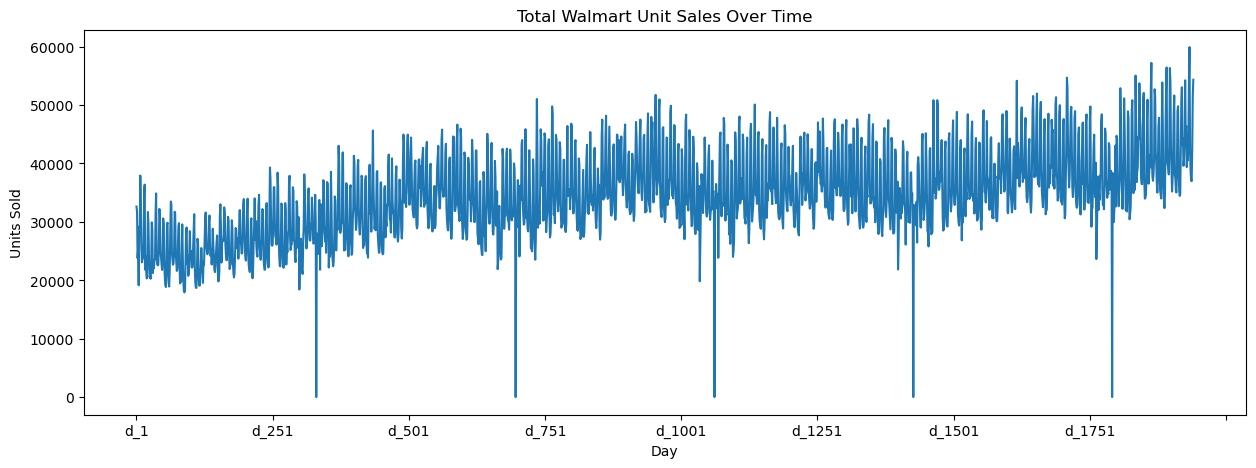

In [11]:
# plot total daily sales
plt.figure(figsize=(15,5))
daily_sales.plot()
plt.title("Total Walmart Unit Sales Over Time")
plt.xlabel("Day")
plt.ylabel("Units Sold")
plt.show()

In [17]:
# how many unique items exist per department?  

dept_counts = (
    sales.groupby(['cat_id', 'dept_id'])['item_id']
         .nunique()
         .reset_index(name='total_items')
)

dept_counts

,cat_id,dept_id,total_items
0,FOODS,FOODS_1,216
1,FOODS,FOODS_2,398
2,FOODS,FOODS_3,823
3,HOBBIES,HOBBIES_1,416
4,HOBBIES,HOBBIES_2,149
5,HOUSEHOLD,HOUSEHOLD_1,532
6,HOUSEHOLD,HOUSEHOLD_2,515


In [19]:
# how many units were sold total by department?

daily_cols = [c for c in sales.columns if c.startswith('d_')]

# Sum all sales within each department
dept_sales = (
    sales.groupby(['cat_id', 'dept_id'])[daily_cols]
         .sum()
         .sum(axis=1)
         .reset_index(name='total_units_sold')
)


dept_sales

,cat_id,dept_id,total_units_sold
0,FOODS,FOODS_1,5190400
1,FOODS,FOODS_2,7795025
2,FOODS,FOODS_3,32937002
3,HOBBIES,HOBBIES_1,5699014
4,HOBBIES,HOBBIES_2,541642
5,HOUSEHOLD,HOUSEHOLD_1,11722853
6,HOUSEHOLD,HOUSEHOLD_2,3041237


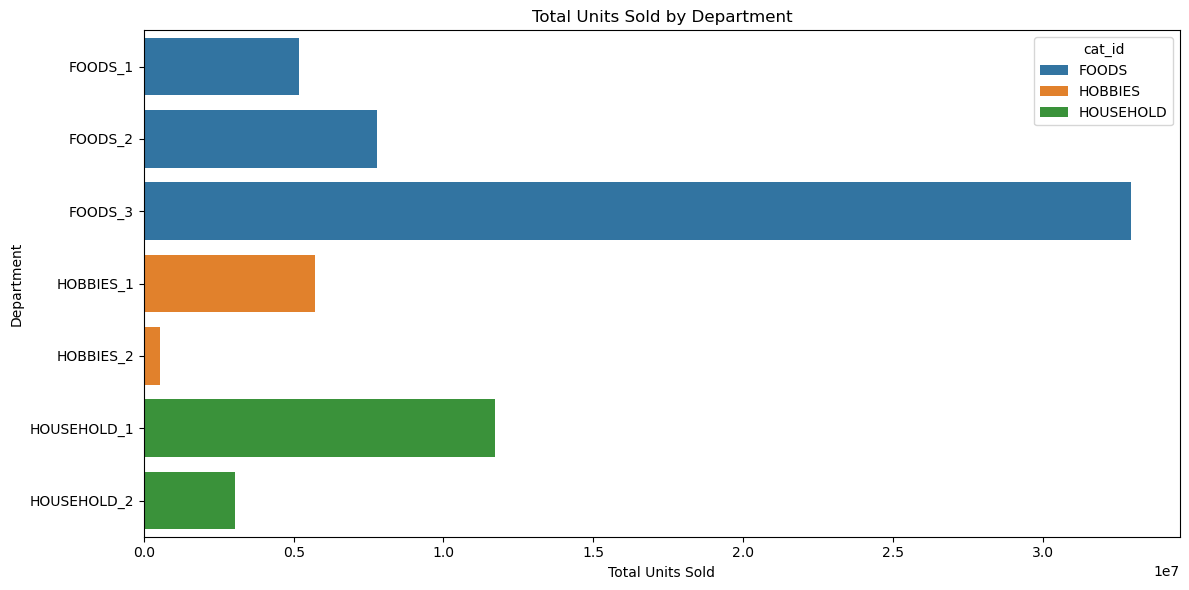

In [20]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=dept_sales,
    x='total_units_sold',
    y='dept_id',
    hue='cat_id'
)

plt.title('Total Units Sold by Department')
plt.xlabel('Total Units Sold')
plt.ylabel('Department')

plt.tight_layout()
plt.show()

In [23]:
# What percentage of total demand comes from each department?

dept_sales['pct_of_total'] = (
    dept_sales['total_units_sold']
    / dept_sales['total_units_sold'].sum()
    * 100
)

dept_sales['pct_total_sales'] = (
    dept_sales['total_units_sold']
    / dept_sales['total_units_sold'].sum()
    * 100
)

dept_sales[['dept_id', 'pct_total_sales']]

,dept_id,pct_total_sales
0,FOODS_1,7.755295
1,FOODS_2,11.647026
2,FOODS_3,49.213198
3,HOBBIES_1,8.515247
4,HOBBIES_2,0.809301
5,HOUSEHOLD_1,17.515835
6,HOUSEHOLD_2,4.544099


In [26]:
# How many items exist in each department and whats the average sales per item in each department?

dept_summary = (
    sales.groupby(['cat_id','dept_id'])[daily_cols]
         .sum()
         .sum(axis=1)
         .reset_index(name='total_units_sold')
)

item_counts = (
    sales.groupby(['cat_id','dept_id'])['item_id']
         .nunique()
         .reset_index(name='num_items')
)

dept_summary = dept_summary.merge(
    item_counts,
    on=['cat_id','dept_id']
)

dept_summary['sales_per_item'] = (
    dept_summary['total_units_sold']
    / dept_summary['num_items']
)

dept_summary


,cat_id,dept_id,total_units_sold,num_items,sales_per_item
0,FOODS,FOODS_1,5190400,216,24029.629630
1,FOODS,FOODS_2,7795025,398,19585.489950
2,FOODS,FOODS_3,32937002,823,40020.658566
3,HOBBIES,HOBBIES_1,5699014,416,13699.552885
4,HOBBIES,HOBBIES_2,541642,149,3635.181208
5,HOUSEHOLD,HOUSEHOLD_1,11722853,532,22035.437970
6,HOUSEHOLD,HOUSEHOLD_2,3041237,515,5905.314563
